<a href="https://colab.research.google.com/github/bpickett14/AdvancedStatisticalMethods/blob/main/WrittenReportChapter3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Brenna Pickett Bunderson - Written Report 3

In [ ]:
install.packages('Sleuth3')
library('Sleuth3')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
head(ex0333)
attach(ex0333)

,BrainSize,LitterSize
,<dbl>,<fct>
1,0.42,Small
2,0.86,Small
3,0.88,Small
4,1.11,Small
5,1.34,Small
6,1.38,Small


#Introduction: Describe the Data and Present the Question
The dataset ex0333 from the Sleuth3 package contains information on relative brain size for 96 species of mammals. Relative brain size is measured as 1000 times the ratio of brain weight to body weight. Each species is also classified by average litter size, which is recorded as a categorical variable with two levels: Small (average litter size less than 2) and Large (average litter size greater than or equal to 2).

This dataset allows for a comparison of brain size across mammals with differing reproductive strategies. Perhaps, mammals that produce smaller litters may invest more biological resources in individual offspring, potentially which may be associated with smaller relative brain sizes compared to species with larger litters.

The primary question raised by this data is: *Is there a difference in relative brain size between mammal species with small litters and those with large litters?*

Answering this question can provide insight into the relationship between reproductive strategy and brain development in mammals.

In [ ]:
summary(ex0333)

   BrainSize      LitterSize
 Min.   : 0.420   Large:45  
 1st Qu.: 2.740   Small:51  
 Median : 6.635             
 Mean   : 8.800             
 3rd Qu.:12.357             
 Max.   :36.350             

In [ ]:
library(dplyr)

mean_brain_sizes <- ex0333 %>%
  group_by(LitterSize) %>%
  summarise(mean_BrainSize = mean(BrainSize, na.rm = TRUE))

print(mean_brain_sizes)

# A tibble: 2 × 2
  LitterSize mean_BrainSize
  <fct>               <dbl>
1 Large               11.0 
2 Small                6.89


#Graphical Analysis

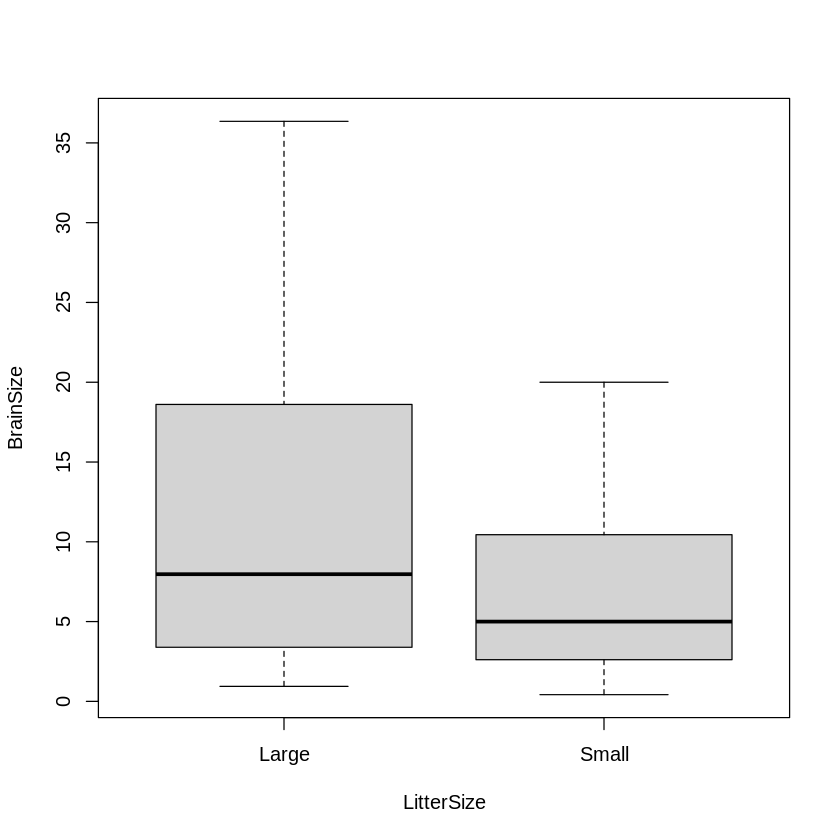

In [ ]:
boxplot(BrainSize ~ LitterSize, data = ex0333)

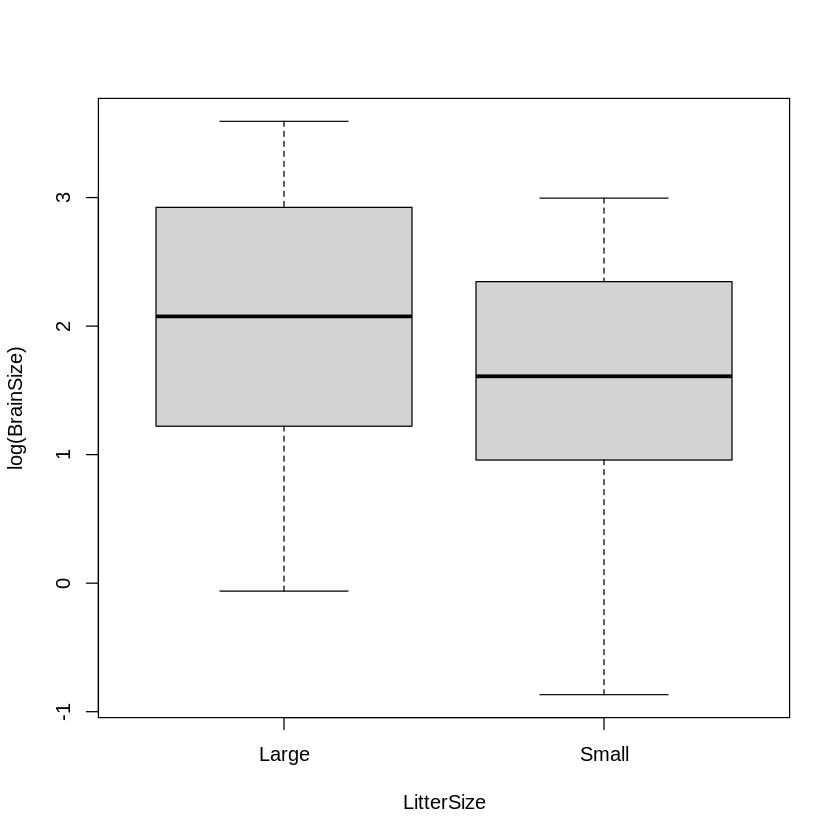

In [ ]:
boxplot(log(BrainSize) ~ LitterSize, data = ex0333)

Oooh! Improved symmetry! This supports the use of the log transformation.

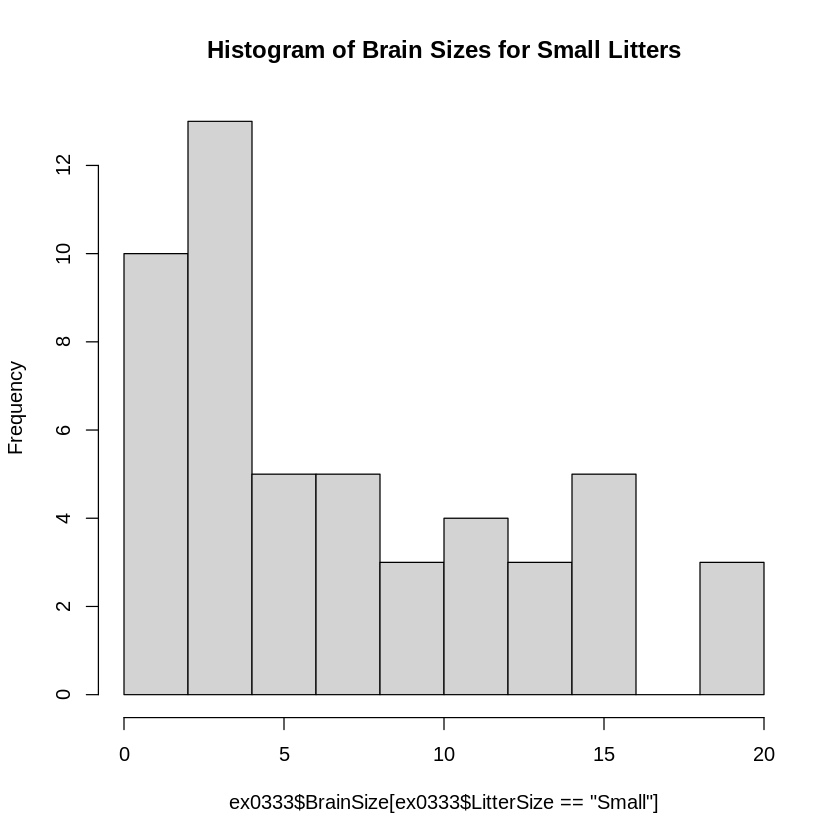

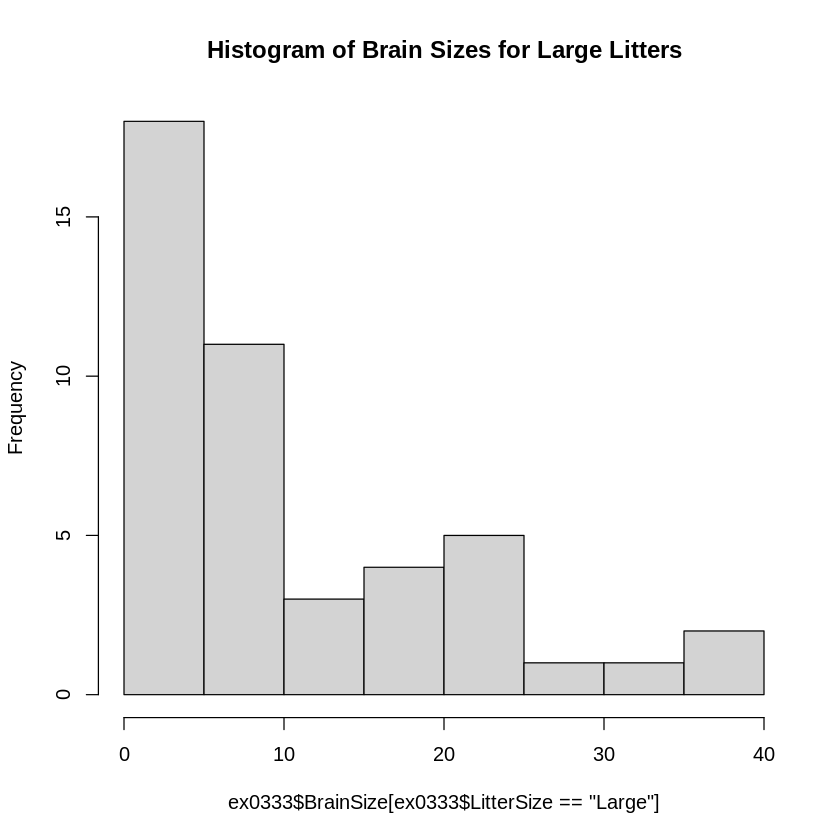

In [ ]:
hist(ex0333$BrainSize[ex0333$LitterSize == 'Small'], main = paste("Histogram of Brain Sizes for Small Litters"))
hist(ex0333$BrainSize[ex0333$LitterSize == 'Large'], main = paste("Histogram of Brain Sizes for Large Litters"))

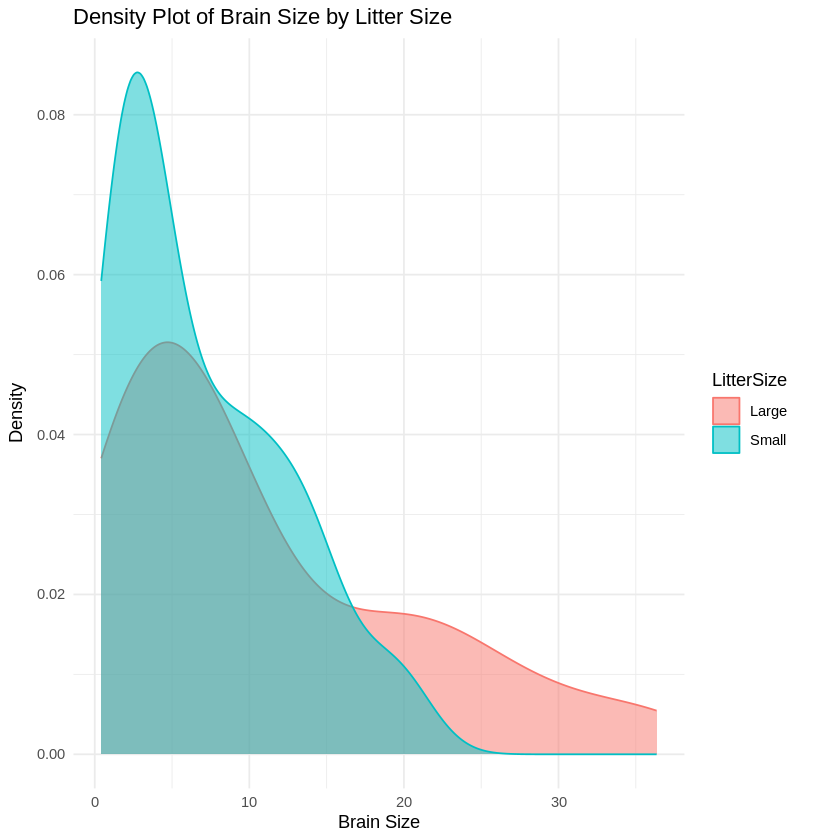

In [ ]:
library(ggplot2)

ggplot(ex0333, aes(x = BrainSize, fill = LitterSize, color = LitterSize)) +
  geom_density(alpha = 0.5) +
  labs(title = "Density Plot of Brain Size by Litter Size",
       x = "Brain Size",
       y = "Density") +
  theme_minimal()

#Assumptions

###Independence
The observations in this dataset represent different mammal species, and each species appears only once. There is no pairing or repeated measurement within species. Additionally, the relative brain size of species with large litter sizes does not influence the brain size of species with small litter sizes. Therefore, the assumption of independent observations is reasonably satisfied.

###Normality
Let's look at normality (we already have had a bit of an experience with that with the box plots above)

In [ ]:
# Perform Shapiro-Wilk test for 'Large' group
Large_Litter <- ex0333 %>%
  filter(LitterSize == "Large") %>%
  select(BrainSize)
shapiro_large <- shapiro.test(Large_Litter$BrainSize)
print(shapiro_large)

# Perform Shapiro-Wilk test for 'Small' group
Small_Litter <- ex0333 %>%
  filter(LitterSize == "Small") %>%
  select(BrainSize)
shapiro_small <- shapiro.test(Small_Litter$BrainSize)
print(shapiro_small)


	Shapiro-Wilk normality test

data:  Large_Litter$BrainSize
W = 0.85683, p-value = 5.515e-05


	Shapiro-Wilk normality test

data:  Small_Litter$BrainSize
W = 0.89377, p-value = 0.0002622



Since both p-values are quite small, we reject the null hypothesis of the distribution being normal. We conclude that the distributions are not normal. What if we do a log transformation as before?

In [ ]:
# Large litter group
Log_Large_Litter <- ex0333 %>%
  filter(LitterSize == "Large") %>%
  mutate(logBrain = log(BrainSize))

shapiro.test(Log_Large_Litter$logBrain)

# Small litter group
Log_Small_Litter <- ex0333 %>%
  filter(LitterSize == "Small") %>%
  mutate(logBrain = log(BrainSize))

shapiro.test(Log_Small_Litter$logBrain)


	Shapiro-Wilk normality test

data:  Log_Large_Litter$logBrain
W = 0.96271, p-value = 0.1548



	Shapiro-Wilk normality test

data:  Log_Small_Litter$logBrain
W = 0.95914, p-value = 0.07667


Shapiro–Wilk tests applied to the log-transformed brain size data yielded p-values of 0.155 for the large litter group and 0.077 for the small litter group, indicating no strong evidence against normality. In addition, each group contains more than 30 observations, and by the Central Limit Theorem the sampling distribution of the mean is approximately normal. Therefore, the normality assumption is reasonably satisfied for the log-transformed data.

In [ ]:
library(dplyr)

# Calculate the sample size for each group (Small/Large)
sample_sizes <- ex0333 %>%
  group_by(LitterSize) %>%
  summarise(count = n())

# Display the sample sizes
print(sample_sizes)

# A tibble: 2 × 2
  LitterSize count
  <fct>      <int>
1 Large         45
2 Small         51


Since the sample size is larger than 30 and the Shapiro test on the Log transformed data seems to be not non-normal. I think we should continue with a variance test.

In [ ]:
install.packages('lawstat')
library(lawstat)

# Perform Levene's test for equality of variances
levene_test_result <- levene.test(y = ex0333$BrainSize, group = ex0333$LitterSize)

# Print the results of Levene's test
print("Levene's Test for Equality of Variances:")
print(levene_test_result)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Levene's Test for Equality of Variances:"

	Modified robust Brown-Forsythe Levene-type test based on the absolute
	deviations from the median

data:  ex0333$BrainSize
Test Statistic = 6.7919, p-value = 0.01065



In [ ]:
library(dplyr)
library(lawstat)

# Create a log-transformed BrainSize variable
ex0333_log <- ex0333 %>%
  mutate(logBrainSize = log(BrainSize))

# Perform Levene's test for equality of variances on log-transformed data
levene_test_log_result <- levene.test(y = ex0333_log$logBrainSize, group = ex0333_log$LitterSize)

# Print the results of Levene's test for log-transformed data
print("Levene's Test for Equality of Variances (Log-Transformed BrainSize):")
print(levene_test_log_result)

[1] "Levene's Test for Equality of Variances (Log-Transformed BrainSize):"

	Modified robust Brown-Forsythe Levene-type test based on the absolute
	deviations from the median

data:  ex0333_log$logBrainSize
Test Statistic = 0.11081, p-value = 0.74



Wow! The null hypothesis for the Levene's Test is that the variances are equal. We fail to reject the null because the p-value is 0.74. This suggests that the assumption of equal variances is reasonable for the log-transformed brain size data.

Let's continue with the t-test of the log transformed data because it fulfills the assumptions better than the raw data.

#Statistical Conclusion
here you will discuss the p-values/confidence intervals and conclusions of that statistical analysis and the methods you used (be sure to address the strength of your conclusions)

In [ ]:
tt_log <- t.test(log(BrainSize) ~ LitterSize, data = ex0333, var.equal = TRUE, alternative = "two.sided")
tt_log


	Two Sample t-test

data:  log(BrainSize) by LitterSize
t = 1.975, df = 94, p-value = 0.0512
alternative hypothesis: true difference in means between group Large and group Small is not equal to 0
95 percent confidence interval:
 -0.00210957  0.79604609
sample estimates:
mean in group Large mean in group Small 
           1.949426            1.552458 


The null-hypothesis is that the brain-sizes of the two litters are the same (or that the difference is 0). The alternative is they are not the same.

However, the p-value is 0.0512. This is pretty difficult, but since there is a heavier amount on the positive side of the logged transformation, I would say there is suggestive but inconclusive evidence that the brain sizes are different between the different brain sizes. I would lean toward rejecting the null hypothesis, but more data is needed to sustainably conclude that.





In [ ]:
exp(tt_log$estimate["mean in group Large"] - tt_log$estimate["mean in group Small"])
exp(tt_log$conf.int)

mean in group Large 
           1.487309

[1] 0.9978927 2.2167587
attr(,"conf.level")
[1] 0.95

Because the analysis was conducted on the log-transformed brain size, the difference in group means corresponds to a ratio of geometric means on the original scale. Exponentiating the estimated difference yields a ratio of approximately 1.49, indicating that species with large litters have a geometric mean relative brain size about 1.5 times that of species with small litters. The 95% confidence interval for this ratio ranges from approximately 1.00 to 2.22.

--> mean in group Large has between 1x and 2.22x bigger brain than group Small

#Scope of Inference
This data colleciton is an observational experiment since you can't assign which mammals has a "large" litter size and which has a "small" litter size. Therefore, the results demonstarte an association rather than a causation.

There is suggestive but inconclusive evidence that larger litter size mammals have bigger brains than smaller litter size mammals. We need more data for it to be more conclusive.

The conclusions apply to mammal species similar to those included in the dataset and during the time period in which the data were collected. While the evidence is statistically significant, the observational nature of the study limits causal interpretation.

In [ ]:
detach(ex0333)